## 1. Introduction

This dataset contains information about visits to [GStore](https://www.googlemerchandisestore.com/) (Google swag online store), sourced from Google Analytics. Each row represents a unique session visit, and each user has a unique 'fullVisitorId'. The dataset has approximately 1.7M rows with multiple users making repeat visits over time.

**Dataset Overview:**

- **Total sessions**: 1,708,337 visits
- **Unique users**: ~1.3 million
- **Time period**: July 2016 - May 2018
- **Target variable**: `totals_transactionRevenue` (log-transformed for modeling)
- **Class imbalance**: Only ~1.08% of sessions have any purchase revenue

**Columns and features:**

The dataset contains JSON-structured fields that expand into:

1. device: browser, OS, device category, mobile flag
2. geoNetwork: country, continent, region, city, metro, network domain
3. totals: hits, pageviews, bounces, new visits, revenue
4. trafficSource: channel, source, medium, campaign, keyword

After expanding JSON and dropping low-variance/high-cardinality features, we work with approximately **58 features** for analysis.

In [1]:
import gc
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle('../data/df_full.pkl')
df.head()

,channelGrouping,date,fullVisitorId,visitId,visitNumber,visitStartTime,device_browser,device_operatingSystem,device_isMobile,device_deviceCategory,...,Date_Is_month_start,Date_Is_quarter_end,Date_Is_quarter_start,Date_Is_year_end,Date_Is_year_start,visitStartTime_datetime,Date_Hour,transactionRevenue,transactionRevenue_dollar,target_log_revenue
0,Organic Search,2017-10-16,3162355547410993243,1508198450,1,1508198450,Firefox,Windows,False,desktop,...,0,0,0,0,0,2017-10-17 00:00:50,0,0.0,0.0,0.0
1,Referral,2017-10-16,8934116514970143966,1508176307,6,1508176307,Chrome,Chrome OS,False,desktop,...,0,0,0,0,0,2017-10-16 17:51:47,17,0.0,0.0,0.0
2,Direct,2017-10-16,7992466427990357681,1508201613,1,1508201613,Chrome,Android,True,mobile,...,0,0,0,0,0,2017-10-17 00:53:33,0,0.0,0.0,0.0
3,Organic Search,2017-10-16,9075655783635761930,1508169851,1,1508169851,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 16:04:11,16,0.0,0.0,0.0
4,Organic Search,2017-10-16,6960673291025684308,1508190552,1,1508190552,Chrome,Windows,False,desktop,...,0,0,0,0,0,2017-10-16 21:49:12,21,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1708337 entries, 0 to 1708336
Data columns (total 59 columns):
 #   Column                                        Dtype         
---  ------                                        -----         
 0   channelGrouping                               object        
 1   date                                          datetime64[ns]
 2   fullVisitorId                                 object        
 3   visitId                                       int64         
 4   visitNumber                                   int64         
 5   visitStartTime                                int64         
 6   device_browser                                object        
 7   device_operatingSystem                        object        
 8   device_isMobile                               bool          
 9   device_deviceCategory                         object        
 10  geoNetwork_continent                          object        
 11  geoNetwork_subContinent            

* Current dataset has 59 columns
* Main target variable: `totals_transactionRevenue` (revenue in microdollars, 10^6 USD)

Let's examine the basic structure of the dataset:

**Key observations**:
- Single dataset with 1.7M+ unique sessions
- Significant class imbalance: most sessions (98.92%) have zero revenue
- Data spans ~22 months of activity

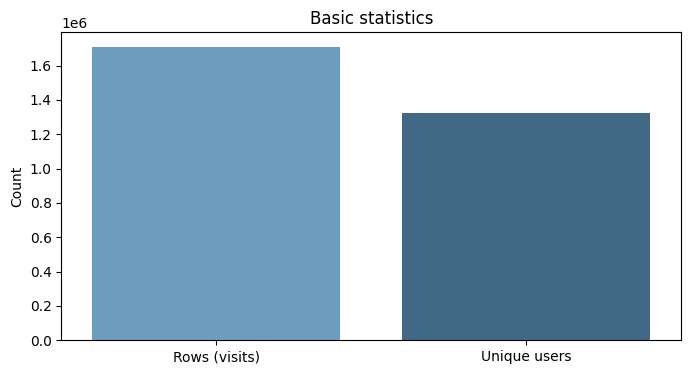

In [4]:
values_name = ['Rows (visits)', 'Unique users']
values = [len(df), df['fullVisitorId'].nunique()]
plt.figure(figsize=(8,4))
plt.title("Basic statistics")
sns.barplot(x=values_name, y=values, palette='Blues_d')
plt.ylabel('Count')
plt.show()

### 1.1 Target variable

The `totals_transactionRevenue` column represents transaction value for each visit. **98.92% of sessions have zero revenue (no purchase)**, representing the class imbalance problem. Revenue values are in microdollars (multiply by 10^-6 to get USD). For modeling, we use log1p transformation to handle:
- Extreme class imbalance (purchasing vs non-purchasing)
- Right-skewed distribution of non-zero revenue
- Better numerical stability in regression models

totals_transactionRevenue has 1708337 non-missing values or 100.000%
Only 1323730 unique users have transactions or 1.000%


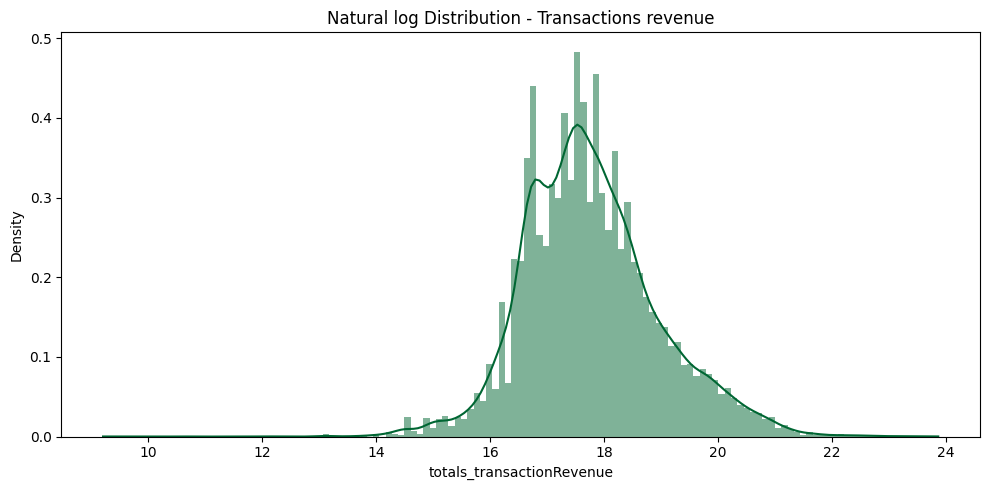

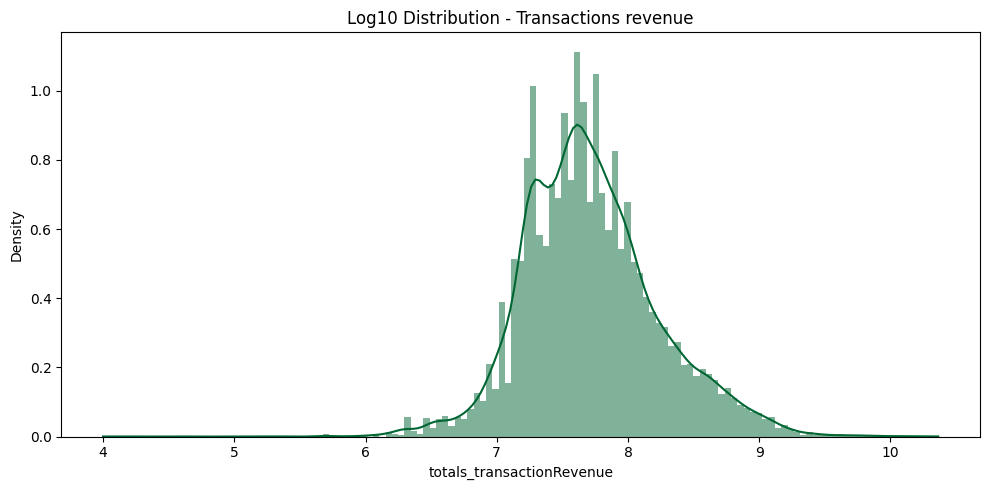

In [5]:
non_missing = len(df[~df['totals_transactionRevenue'].isnull()])
num_visitors = df[~df['totals_transactionRevenue'].isnull()]['fullVisitorId'].nunique()
print("totals_transactionRevenue has {} non-missing values or {:.3f}%"
      .format(non_missing, 100*non_missing/len(df)))
print("Only {} unique users have transactions or {:.3f}%"
      .format(num_visitors, num_visitors/df['fullVisitorId'].nunique()))
# Logn Distplot
revenue = df['totals_transactionRevenue'].dropna().astype('float64')
plt.figure(figsize=(10,5))
plt.title("Natural log Distribution - Transactions revenue")
sns.histplot(np.log(revenue[revenue > 0]), color="#006633", kde=True, stat="density", edgecolor=None)
plt.tight_layout()
plt.show()
# Log10 Distplot
plt.figure(figsize=(10,5))
plt.title("Log10 Distribution - Transactions revenue")
sns.histplot(np.log10(revenue[revenue > 0]), color="#006633", kde=True, stat="density", edgecolor=None)
plt.tight_layout()
plt.show()
# Fill missing with 0 and convert to numerical
df['totals_transactionRevenue'] = df['totals_transactionRevenue'].fillna(0).astype('float64')

Among the ~600k sessions with purchases, revenue spans from small transactions to very large orders. The high variability in revenue amounts reflects the diversity of customer purchases (apparel, electronics, accessories).

Let's examine the aggregated revenue per user (sum of all their transactions):

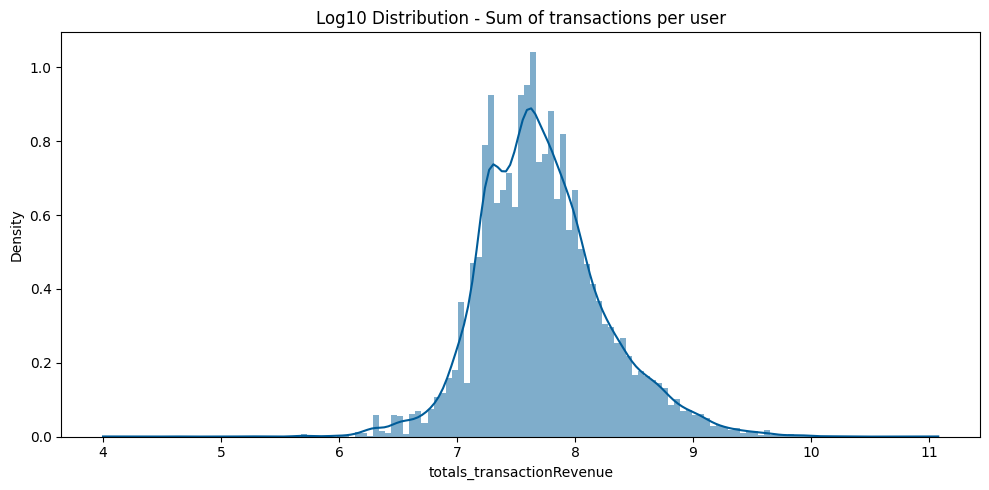

In [6]:
g = df[df['totals_transactionRevenue'] > 0][['fullVisitorId', 'totals_transactionRevenue']]
sum_transactions = g.groupby('fullVisitorId')['totals_transactionRevenue'].sum()
plt.figure(figsize=(10,5))
plt.title("Log10 Distribution - Sum of transactions per user")
sns.histplot(np.log10(sum_transactions), color="#005c99", kde=True, stat="density", edgecolor=None)
plt.tight_layout()
plt.show()

<b>1.2 Timeseries</b>

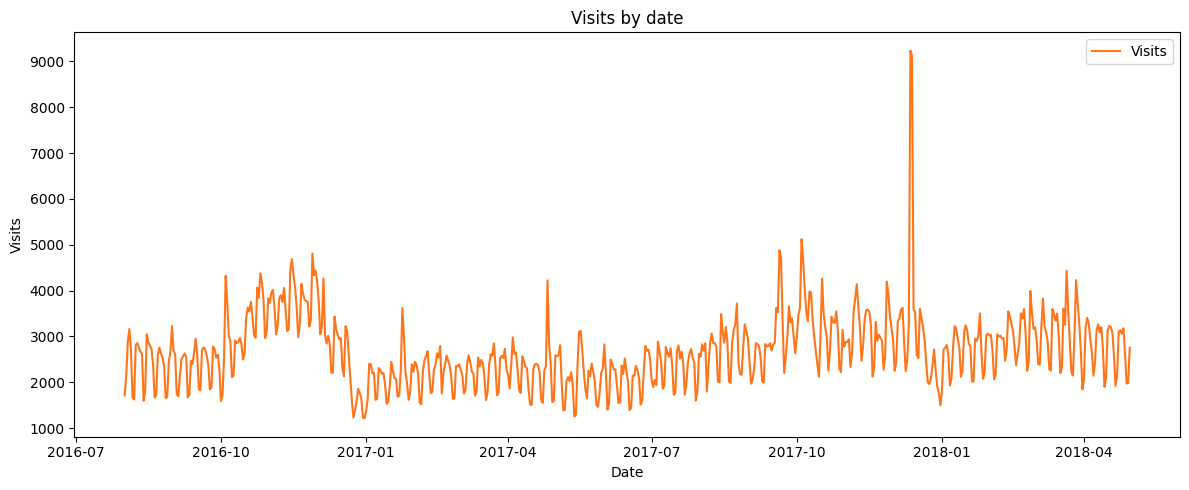

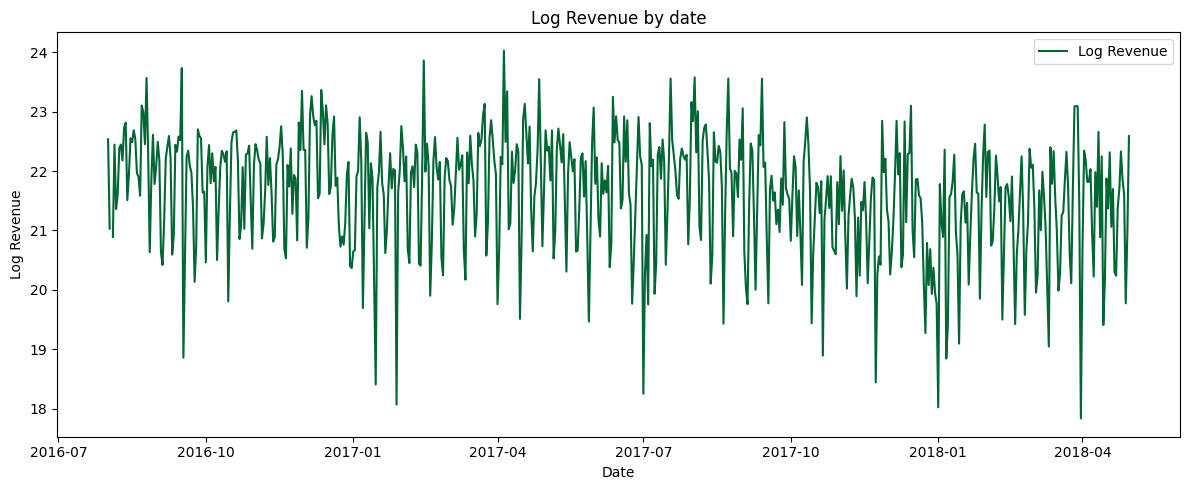

In [7]:
# Visits by time
tmp_df = df['date'].value_counts().to_frame().reset_index()
tmp_df.columns = ['date', 'visits']
tmp_df = tmp_df.sort_values('date')
plt.figure(figsize=(12,5))
plt.plot(tmp_df['date'], tmp_df['visits'], color='#ff751a', label='Visits')
plt.title('Visits by date')
plt.xlabel('Date')
plt.ylabel('Visits')
plt.legend()
plt.tight_layout()
plt.show()
# Revenue by time
df_date_sum = df.groupby('date')['totals_transactionRevenue'].sum().to_frame().reset_index()
plt.figure(figsize=(12,5))
plt.plot(df_date_sum['date'], np.log(df_date_sum['totals_transactionRevenue'].replace(0, np.nan)), color='#006633', label='Log Revenue')
plt.title('Log Revenue by date')
plt.xlabel('Date')
plt.ylabel('Log Revenue')
plt.legend()
plt.tight_layout()
plt.show()

### 1.3 Missing values

Missing values are concentrated in:
- **Very high (>75%)**: `trafficSource_campaign` (~94%), `geoNetwork_metro` (~77%)
- **High (50-75%)**: `geoNetwork_city` (~58%), `geoNetwork_region` (~57%)
- **Medium (30-50%)**: `geoNetwork_networkDomain` (~45%), `trafficSource_medium` (~33%)
- **Low (<5%)**: Most other columns have minimal missing data

These missing patterns reflect natural GA data collection: not all sessions include detailed location data or campaign info.

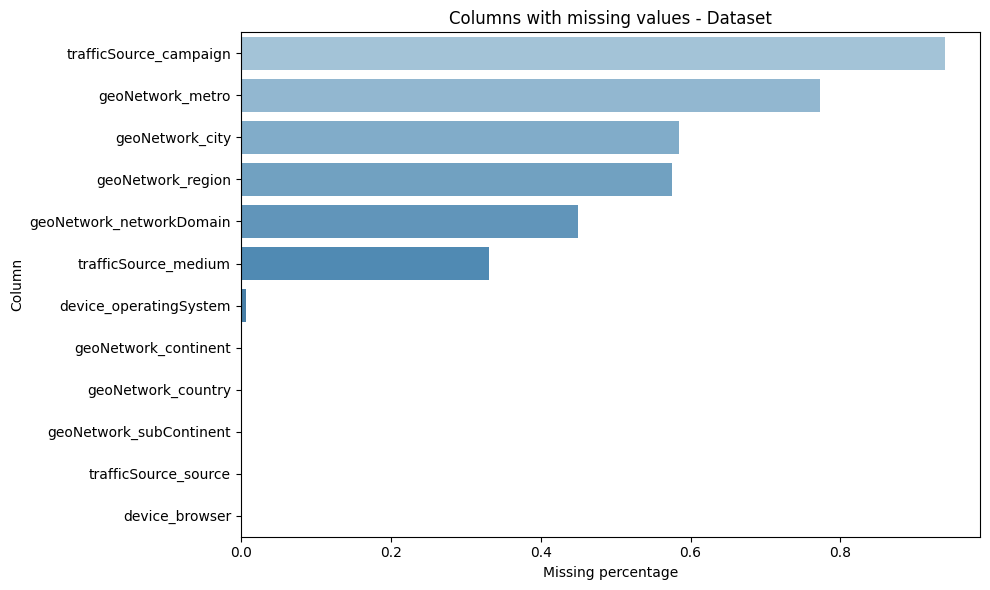

In [50]:
def missing_plot(frame, set_name, palette):
    nan_ratio = frame.isna().sum()/len(frame)
    nan_ratio = nan_ratio.to_frame().reset_index().rename({'index': 'column', 0: 'missing_percentage'},axis=1)
    nan_ratio.sort_values(by=['missing_percentage'], ascending=False, inplace=True)
    plt.figure(figsize=(10,6))
    plt.title("Columns with missing values - {}".format(set_name))
    sns.barplot(x='missing_percentage', y='column', orient='h',
                data=nan_ratio[nan_ratio['missing_percentage'] > 0],
                palette= palette)
    plt.xlabel('Missing percentage')
    plt.ylabel('Column')
    plt.tight_layout()
    plt.show()

missing_plot(df, 'Dataset', 'Blues_d')

### 1.4 Constant features

Constant-value columns (identical value across all rows) provide no predictive information and should be removed. These typically include deprecated fields or fields that don't vary in this dataset.

In [9]:
df_const_cols = [c for c in df.columns if len(df[c].unique()) == 1]
print("{} columns with a unique value".format(len(df_const_cols)))
df.drop(df_const_cols, axis=1, inplace=True)
print("Shape after dropping: {}".format(df.shape))
# Flag visits with revenue
df['has_revenue'] = df['totals_transactionRevenue'].apply(lambda x: 1 if x > 0 else 0)

1 columns with a unique value
Shape after dropping: (1708337, 58)


<h2> 2. Channels and visit number</h2>

**Channel grouping**

Traffic is segmented into 8 channels based on how users arrived:

* **Referral** (highest conversion): Users arriving from external websites - most engaged group
* **Display**: Users from display ad impressions
* **Paid Search**: Paid search ads (Google Ads, Bing, etc.)
* **Direct**: Users typing URL directly or using bookmarks
* **Organic Search**: Users from organic search results
* **Social**: Users from social media platforms
* **Affiliates**: Partner/affiliate traffic
* **(Other)**: Unclassified or miscellaneous traffic

Plots show visit distribution, conversion rate by channel, and average revenue per channel.

In [10]:
def barplot_percentage(count_feat, color1='#3776ab', num_bars=None):
    df_channel = 100*df[count_feat].value_counts()/len(df)
    df_channel = df_channel.to_frame().reset_index()
    df_channel.columns = [count_feat, 'percentage']
    if num_bars:
        df_channel = df_channel.head(num_bars)
    plt.figure(figsize=(10,5))
    sns.barplot(x=count_feat, y='percentage', data=df_channel, color=color1)
    plt.title(f'{count_feat} grouping')
    plt.ylabel('Percentage of visits')
    plt.xlabel(count_feat)
    plt.tight_layout()
    plt.show()

In [11]:
df['channelGrouping'].value_counts()   

channelGrouping
Organic Search    738963
Social            354971
Direct            273134
Referral          211307
Display            51283
Paid Search        45627
Affiliates         32915
(Other)              137
Name: count, dtype: int64

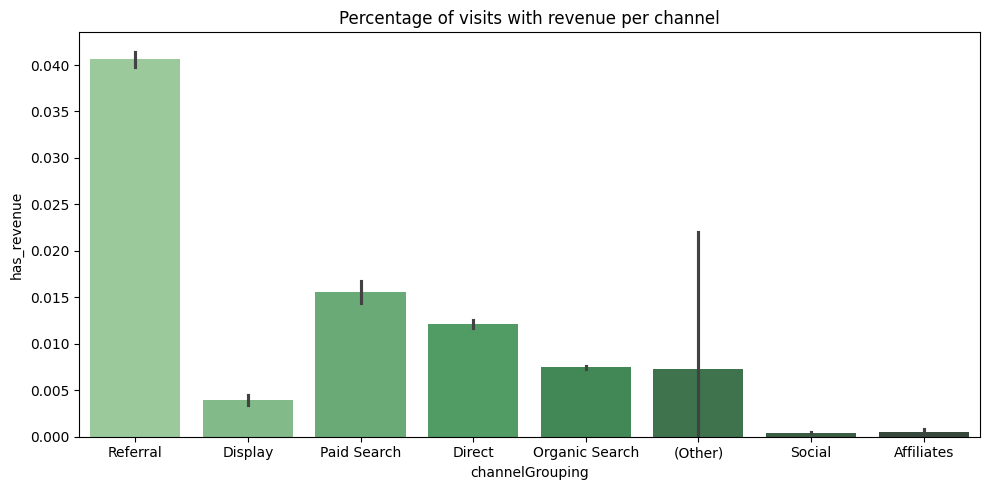

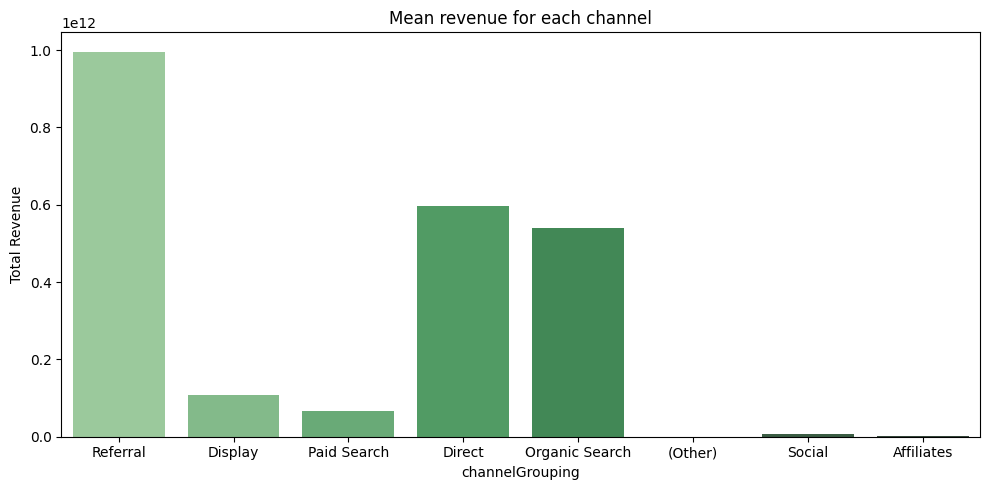

In [12]:
channel_order = ['Referral', 'Display', 'Paid Search', 'Direct', 'Organic Search', '(Other)', 'Social', 'Affiliates']
plt.figure(figsize=(10,5))
plt.title("Percentage of visits with revenue per channel")
sns.barplot(x='channelGrouping', y='has_revenue', data=df, order=channel_order, palette='Greens_d')
plt.tight_layout()
plt.show()
revenue_channel = df.groupby('channelGrouping')['totals_transactionRevenue'].sum()
revenue_channel = revenue_channel.to_frame().reset_index()
plt.figure(figsize=(10,5))
plt.title("Mean revenue for each channel")
sns.barplot(x='channelGrouping', y='totals_transactionRevenue', data=revenue_channel, order=channel_order, palette='Greens_d')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

**Visit Number**

This represents how many visits each user has made. The distribution shows repeat user behavior - most users are one-time visitors, while a small fraction returns multiple times for additional purchases.

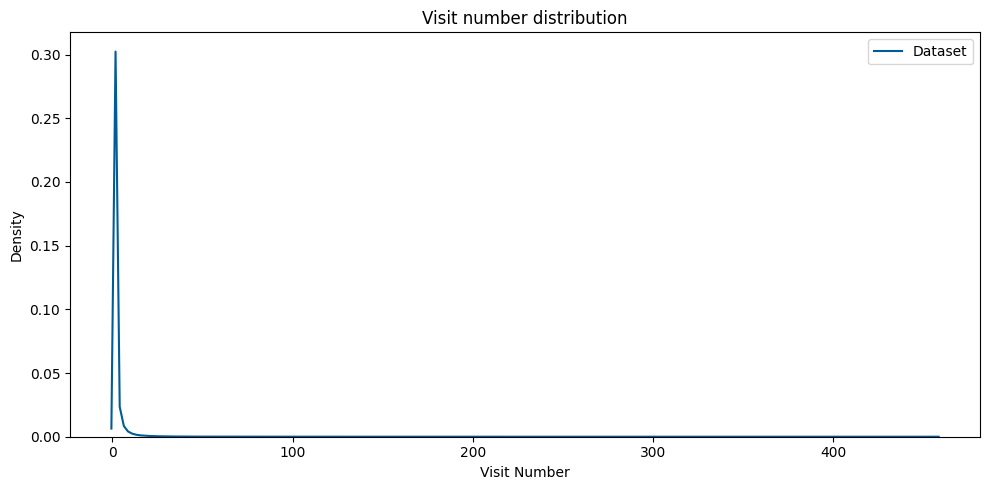

In [13]:
plt.figure(figsize=(10,5))
plt.title("Visit number distribution")
sns.kdeplot(df['visitNumber'], label='Dataset', color="#005c99")
plt.xlabel('Visit Number')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

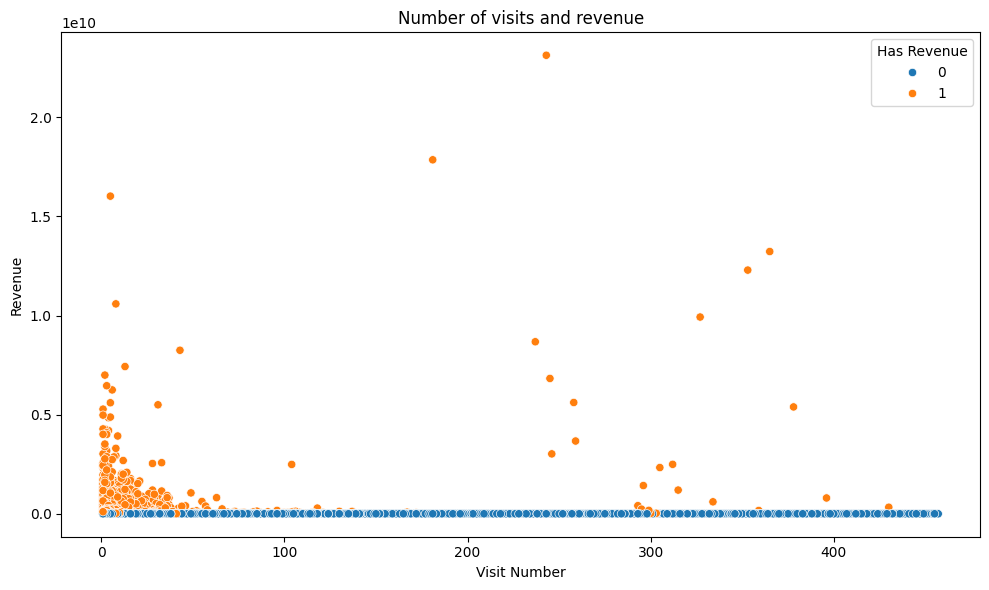

In [14]:
plt.figure(figsize=(10,6))
plt.title("Number of visits and revenue")
sns.scatterplot(x='visitNumber', y='totals_transactionRevenue', data=df, color='orange', hue='has_revenue')
plt.xlabel('Visit Number')
plt.ylabel('Revenue')
plt.legend(loc='upper right', title='Has Revenue')
plt.tight_layout()
plt.show()

<h2>3. Geographic Data</h2>

Now let's look at each specific section: geoNetwork, totals, device and trafficSource

<h3>3.1 Location</h3>

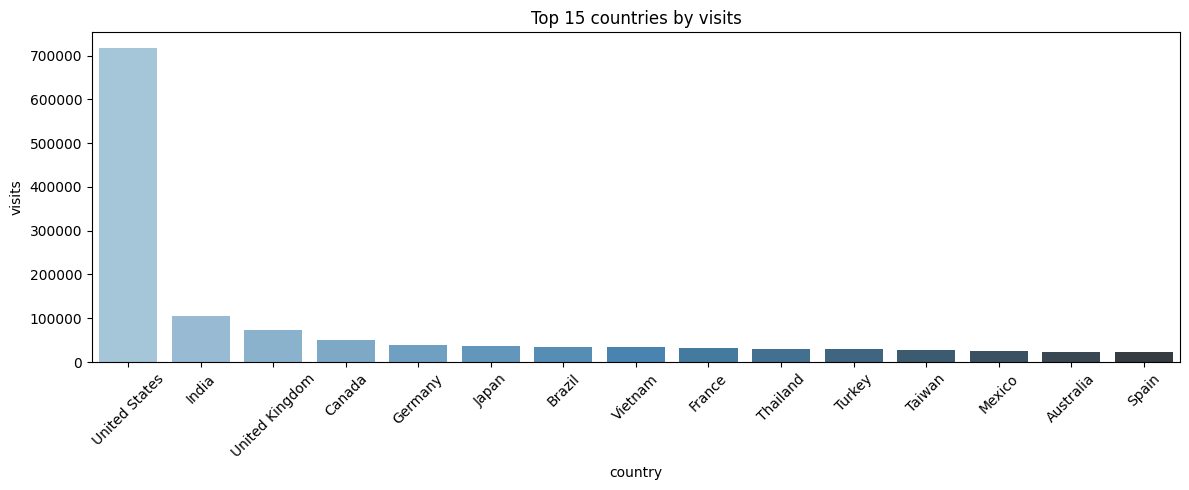

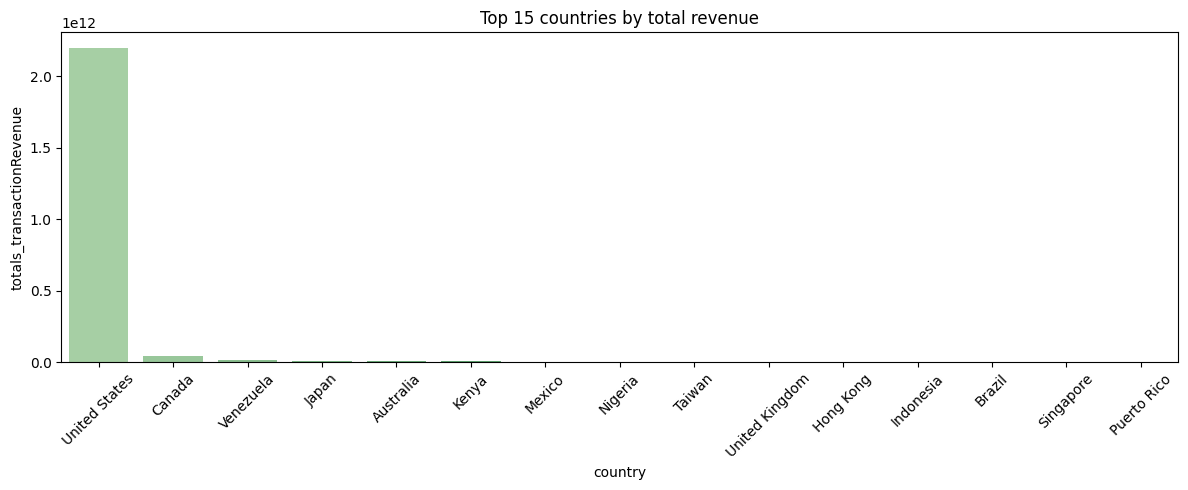

In [15]:
# Bỏ vẽ bản đồ plotly, thay bằng barplot top quốc gia
tmp = df["geoNetwork_country"].value_counts().to_frame().reset_index()
tmp.columns = ["country", "visits"]
plt.figure(figsize=(12,5))
sns.barplot(x="country", y="visits", data=tmp.head(15), palette="Blues_d")
plt.title("Top 15 countries by visits")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

tmp = df.groupby("geoNetwork_country")["totals_transactionRevenue"].sum().to_frame().reset_index()
tmp.columns = ["country", "totals_transactionRevenue"]
plt.figure(figsize=(12,5))
sns.barplot(x="country", y="totals_transactionRevenue", data=tmp.sort_values("totals_transactionRevenue", ascending=False).head(15), palette="Greens_d")
plt.title("Top 15 countries by total revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Check exact US statistics
us_visits = len(df[df['geoNetwork_country'] == 'United States'])
total_visits = len(df)
us_visits_pct = (us_visits / total_visits) * 100

us_revenue = df[df['geoNetwork_country'] == 'United States']['totals_transactionRevenue'].sum()
total_revenue = df['totals_transactionRevenue'].sum()
us_revenue_pct = (us_revenue / total_revenue) * 100

print(f"US visits: {us_visits:,} ({us_visits_pct:.2f}%)")
print(f"Total visits: {total_visits:,}")
print(f"US revenue: {us_revenue:,.0f} ({us_revenue_pct:.2f}%)")
print(f"Total revenue: {total_revenue:,.0f}")
print()
print("Top 3 countries by visits %:")
top_visits = df['geoNetwork_country'].value_counts(normalize=True).head(3)
for country, pct in top_visits.items():
    print(f"  {country}: {pct*100:.2f}%")
print()
print("Top 3 countries by revenue %:")
total_rev_by_country = df.groupby('geoNetwork_country')['totals_transactionRevenue'].sum()
top_revenue_pct = (total_rev_by_country / total_revenue).sort_values(ascending=False).head(3)
for country, pct in top_revenue_pct.items():
    print(f"  {country}: {pct*100:.2f}%")

US visits: 717,217 (41.98%)
Total visits: 1,708,337
US revenue: 2,197,885,190,000 (94.89%)
Total revenue: 2,316,344,980,000

Top 3 countries by visits %:
  United States: 42.05%
  India: 6.17%
  United Kingdom: 4.30%

Top 3 countries by revenue %:
  United States: 94.89%
  Canada: 1.84%
  Venezuela: 0.60%


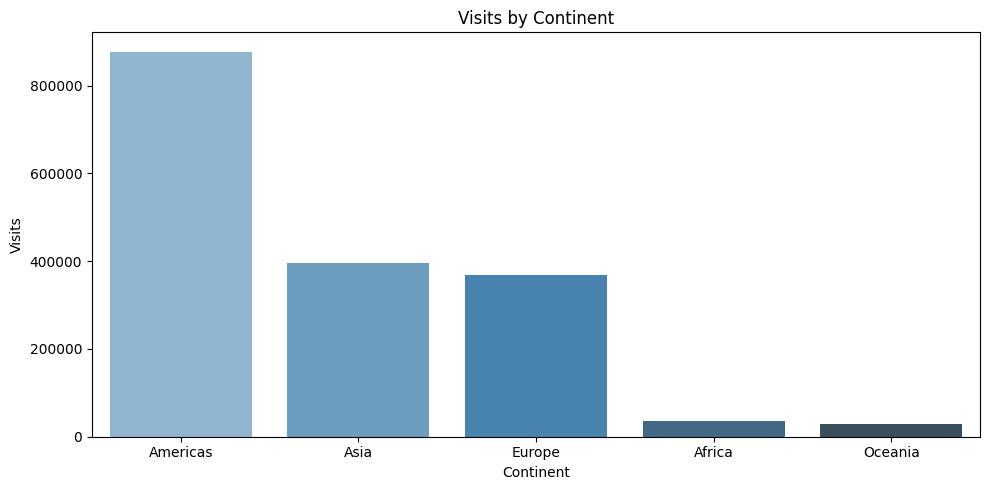

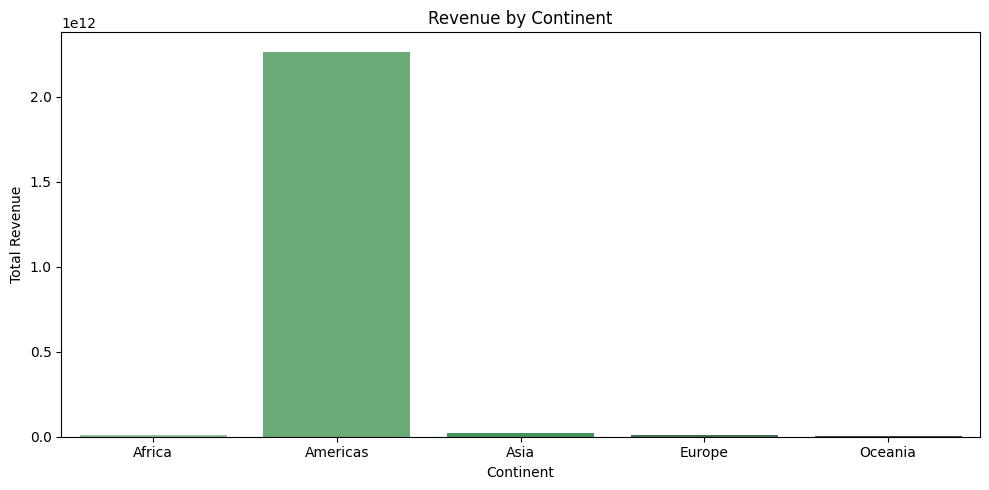

In [17]:
tmp1 = df["geoNetwork_continent"].value_counts().to_frame().reset_index()
tmp1.columns = ["geoNetwork_continent", "visits"]
tmp2 = df.groupby("geoNetwork_continent")["totals_transactionRevenue"].sum().to_frame().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(x='geoNetwork_continent', y='visits', data=tmp1, palette='Blues_d')
plt.title('Visits by Continent')
plt.xlabel('Continent')
plt.ylabel('Visits')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
sns.barplot(x='geoNetwork_continent', y='totals_transactionRevenue', data=tmp2, palette='Greens_d')
plt.title('Revenue by Continent')
plt.xlabel('Continent')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

**US Dominance**: United States generates ~42% of visits but accounts for > 94% of total revenue. This reflects:
- Higher purchase intent from US visitors
- Higher average order value (AOV) from US customers
- Possible currency/payment convenience for US shoppers

International markets (India, UK, Canada) provide significant traffic volume but minimal revenue contribution.

### 3.2 Network domain

Network domain (ISP/company network) shows which ISPs/organizations users connect from. However, this field has:
- Extreme high cardinality (40k+ unique values)
- Limited predictive value (ISP doesn't drive purchase decisions)
- Typical use case: filtering out internal corporate traffic

Top domains shown below (note: most are mobile/ISP carriers, not predictive for commerce):

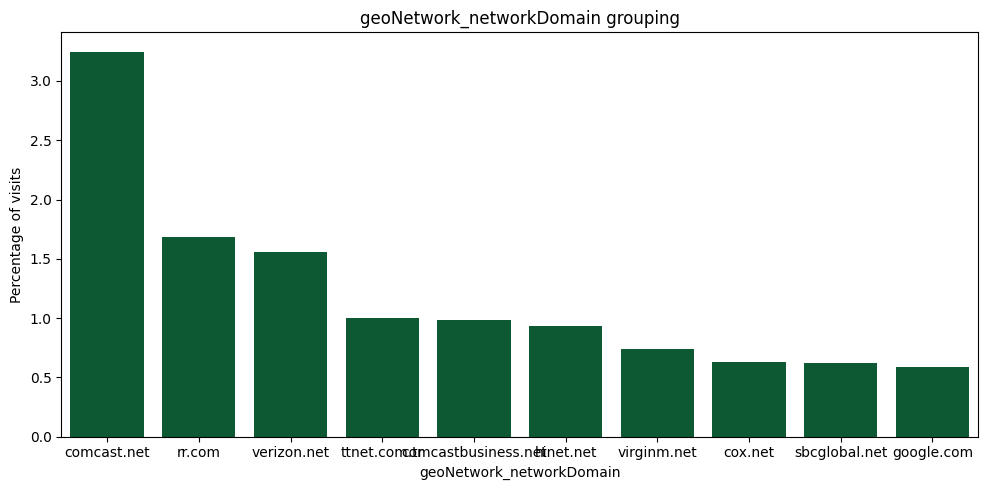

In [18]:
barplot_percentage('geoNetwork_networkDomain', num_bars= 10, color1='#006633')

<h2>4. totals</h2>

There are four features in totals: hits, pageviews, bounces and newVisits.

### 4.1 Bounces

The `totals_bounces` column is binary (0 = didn't bounce, 1 = bounced). 
- **Bounce** = session with only 1 page view (user left immediately)
- **Non-bounce** = session with 2+ page views

Key insight: Bounced sessions (single page visits) have **zero revenue**. This makes logical sense - customers need to browse multiple products/pages to make a purchase.

Revenue for bounce missing: 0.0, revenue for bounce '1': 2316344980000.0


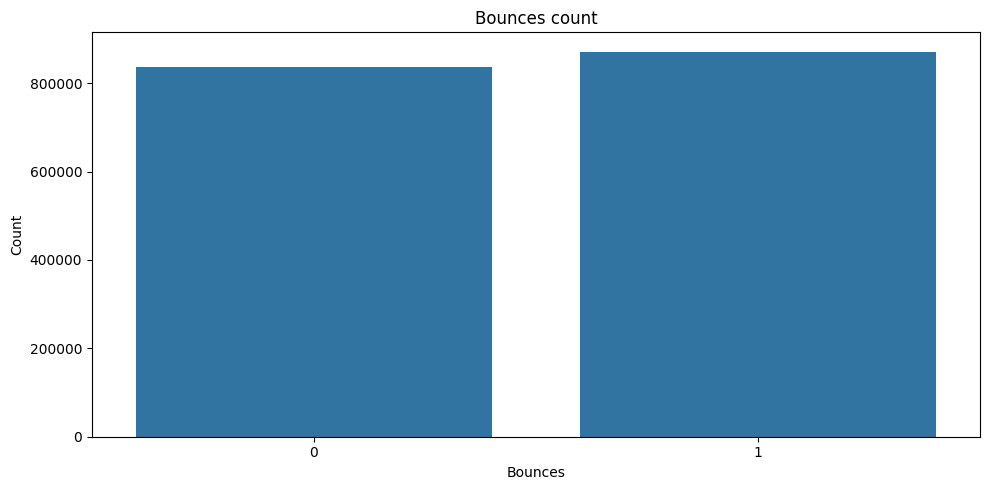

In [19]:
bounces_nan = df[df['totals_bounces'].isnull()]['totals_transactionRevenue'].sum()
bounces_1 = df[~df['totals_bounces'].isnull()]['totals_transactionRevenue'].sum()
print("Revenue for bounce missing: {}, revenue for bounce '1': {}".format(bounces_nan, bounces_1))
plt.figure(figsize=(10,5))
plt.title("Bounces count")
sns.countplot(x='totals_bounces', data=df.fillna('nan'))
plt.xlabel('Bounces')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 New Visits

Binary indicator: 1 = first-time visitor to site, 0 = returning customer. This helps segment:
- **New users**: Discovery phase, first conversion typically lower
- **Returning customers**: Higher intent, familiar with products

Distribution shown below:

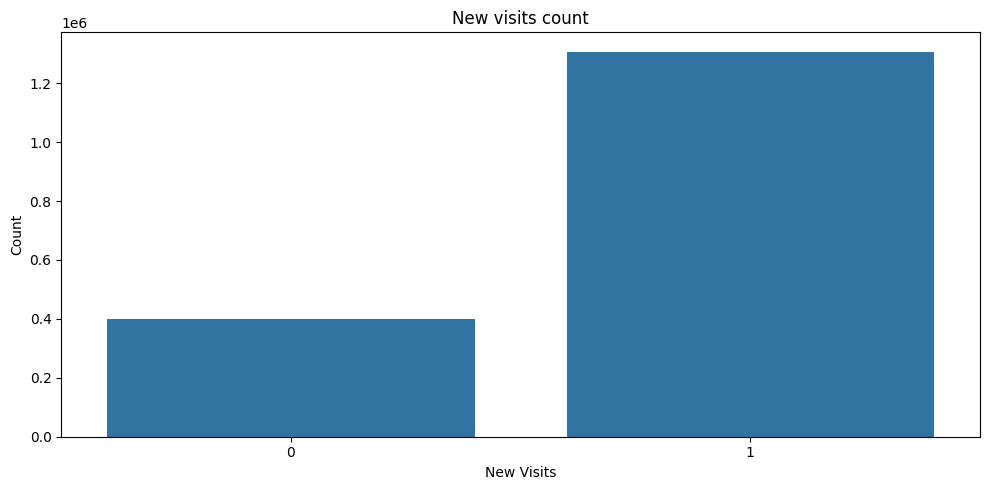

In [20]:
plt.figure(figsize=(10,5))
plt.title("New visits count")
sns.countplot(x='totals_newVisits', data=df.fillna('nan'))
plt.xlabel('New Visits')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.3 Hits

**Hits** = total number of interactions/pageviews in a session (min=1, max=500)
- **Low hits (1-5)**: Landing page visits, quick browsing
- **Medium hits (5-20)**: Product exploration
- **High hits (20+)**: Intensive shopping, comparison browsing

Key finding: Sessions with revenue have significantly higher hits on average, indicating engagement drives conversion.

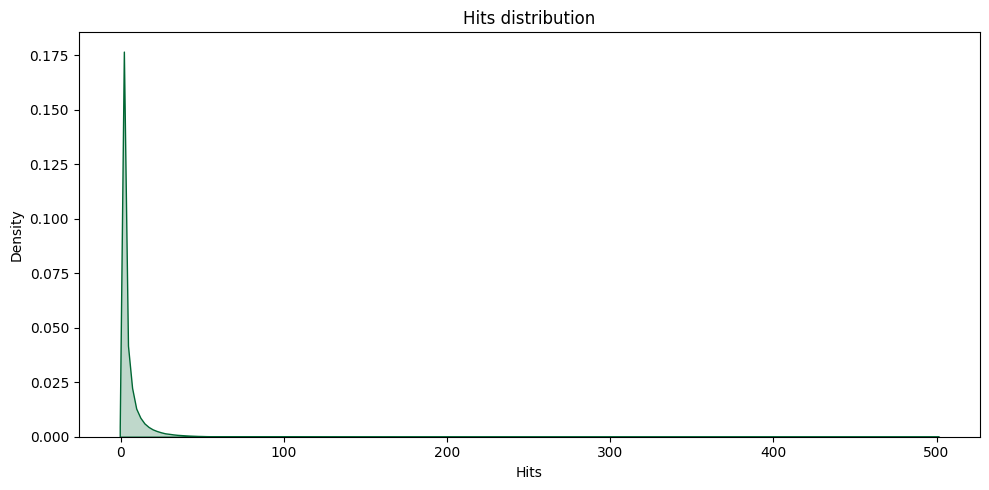

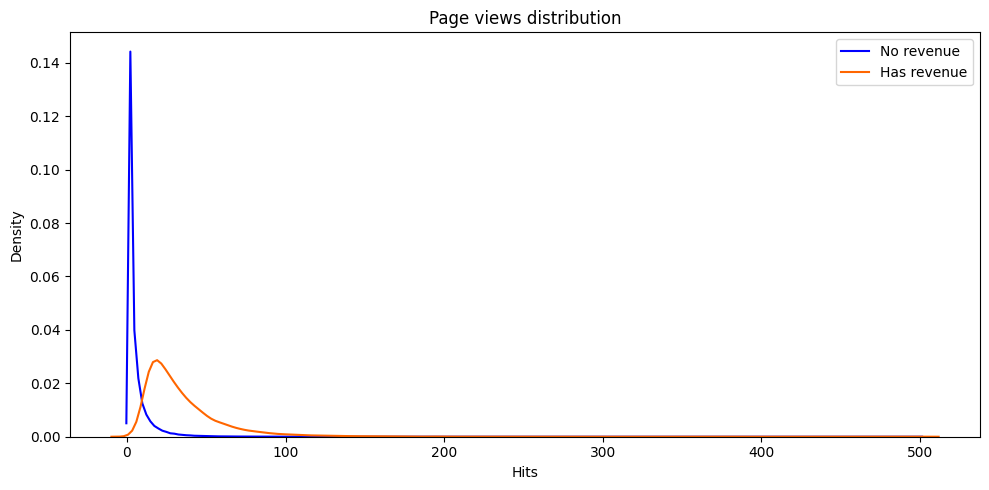

In [21]:
plt.figure(figsize=(10,5))
plt.title("Hits distribution")
sns.kdeplot(df['totals_hits'].astype('float64'), color="#006633", shade=True)
plt.xlabel('Hits')
plt.ylabel('Density')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
plt.title("Page views distribution")
sns.kdeplot(df[df['has_revenue'] == 0]['totals_hits'].astype('float64'), label='No revenue', color="#0000ff")
sns.kdeplot(df[df['has_revenue'] == 1]['totals_hits'].astype('float64'), label='Has revenue', color="#ff6600")
plt.xlabel('Hits')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

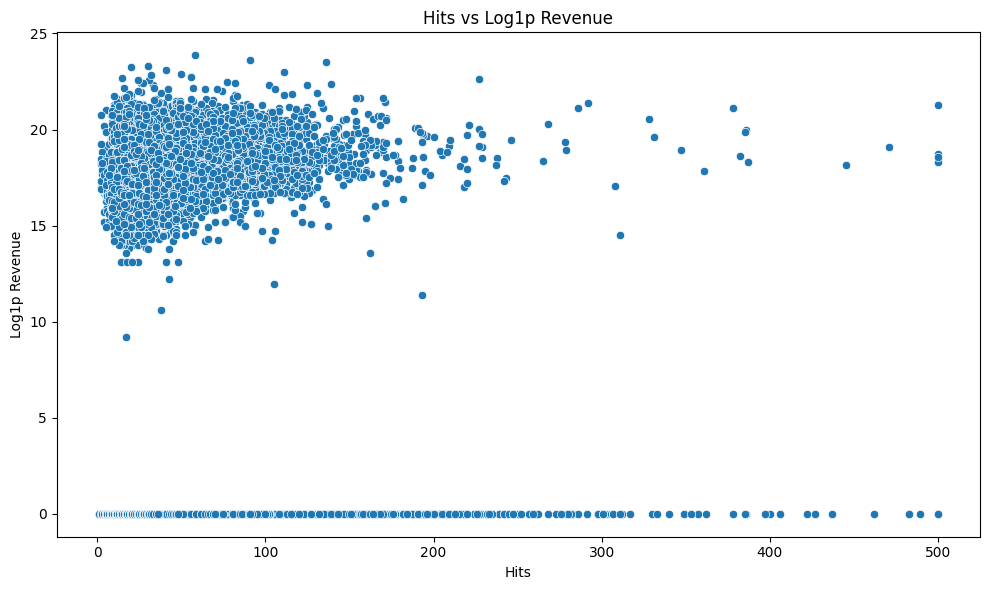

In [22]:
plt.figure(figsize=(10,6))
plt.title("Hits vs Log1p Revenue")
sns.scatterplot(x=df['totals_hits'].astype('float64'), y=np.log1p(df['totals_transactionRevenue']))
plt.xlabel('Hits')
plt.ylabel('Log1p Revenue')
plt.tight_layout()
plt.show()

**Insight**: Customers who make purchases typically have 20-100 hits per session, indicating they browse multiple items before buying. The strong separation between revenue vs. no-revenue distributions makes hits a valuable predictive feature.

### 4.4 Page views

**Page views** = number of distinct pages viewed (highly correlated with hits but represents unique pages). Missing values are minimal, indicating solid data quality.

Similar to hits, page views show clear separation:
- Non-buyers: 1-2 pages (quick exits)
- Buyers: 10-50+ pages (deliberate shopping)

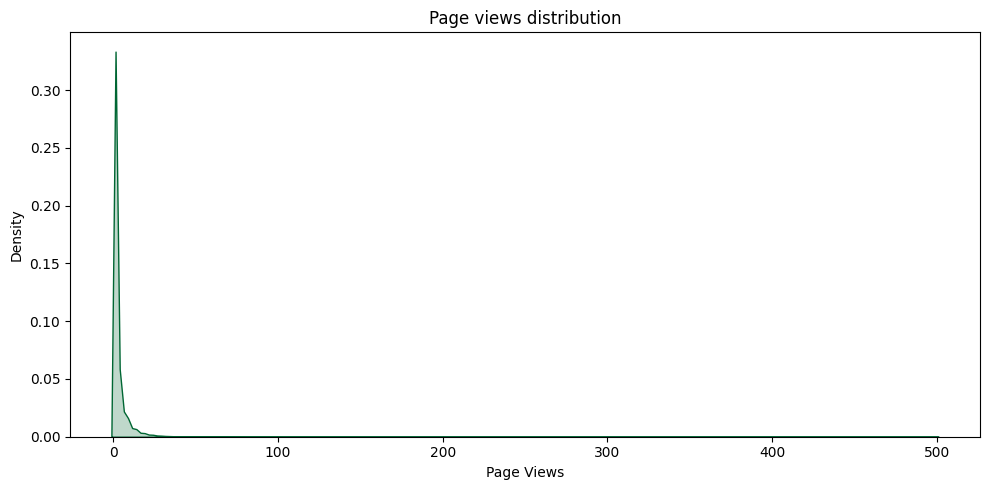

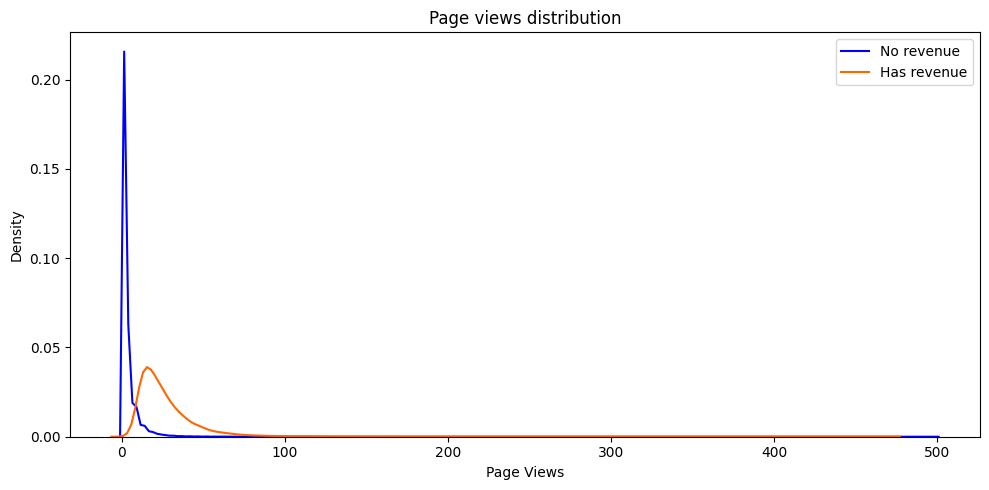

In [23]:
plt.figure(figsize=(10,5))
plt.title("Page views distribution")
sns.kdeplot(df['totals_pageviews'].dropna().astype('float64'), color="#006633", shade=True)
plt.xlabel('Page Views')
plt.ylabel('Density')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10,5))
plt.title("Page views distribution")
sns.kdeplot(df[df['has_revenue'] == 0]['totals_pageviews'].dropna().astype('float64'), label='No revenue', color="#0000ff")
sns.kdeplot(df[df['has_revenue'] == 1]['totals_pageviews'].dropna().astype('float64'), label='Has revenue', color="#ff6600")
plt.xlabel('Page Views')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

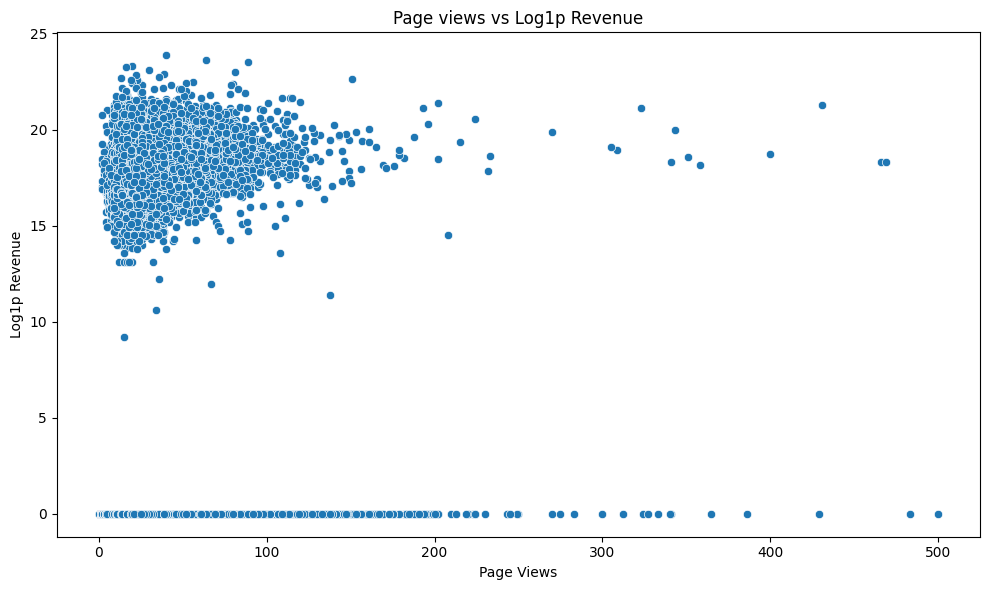

In [24]:
plt.figure(figsize=(10,6))
plt.title("Page views vs Log1p Revenue")
sns.scatterplot(x=df['totals_pageviews'].dropna().astype('float64'), y=np.log1p(df['totals_transactionRevenue']))
plt.xlabel('Page Views')
plt.ylabel('Log1p Revenue')
plt.tight_layout()
plt.show()

And the two numerical features combined:

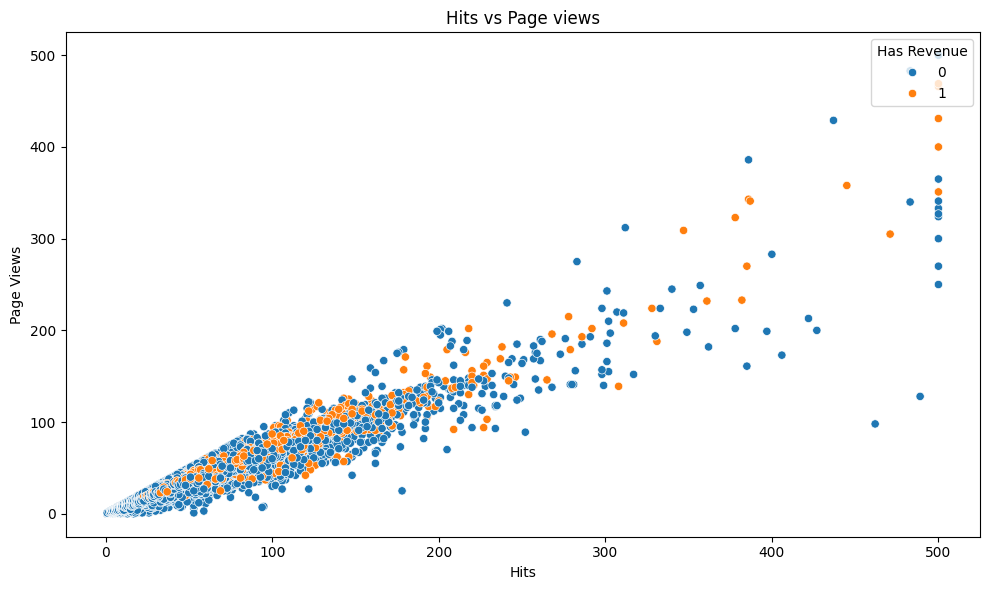

In [25]:
plt.figure(figsize=(10,6))
plt.title("Hits vs Page views")
tmp = df[['totals_hits', 'totals_pageviews', 'has_revenue']].copy()
tmp['totals_hits'] = tmp['totals_hits'].astype('float64')
tmp['totals_pageviews'] = tmp['totals_pageviews'].dropna().astype('float64')
sns.scatterplot(x='totals_hits', y='totals_pageviews', hue='has_revenue', data=tmp)
plt.xlabel('Hits')
plt.ylabel('Page Views')
plt.legend(loc='upper right', title='Has Revenue')
plt.tight_layout()
plt.show()

## 5. Device Information

Device data provides context on how users access the store:
* **device_browser**: 128+ unique browsers (Chrome, Safari, Firefox, Edge, etc.) - most have zero revenue
* **device_operatingSystem**: 20+ operating systems (Windows, macOS, iOS, Android, etc.)
* **device_deviceCategory**: 3 categories (desktop, mobile, tablet) - desktop dominates revenue
* **device_isMobile**: Boolean flag indicating mobile vs. desktop access

**Key pattern**: Desktop users generate significantly more revenue per session than mobile users, likely due to better purchase experience on larger screens.

### 5.1 Browser

**Chrome** dominates with ~69% of all visits and majority of revenue. However, other browsers show interesting patterns:
- **Firefox**: Smaller share but high mean revenue per purchase
- **Safari**: Significant traffic from iOS devices, moderate conversion
- **Edge, IE, Others**: Minimal traffic and revenue contribution

Note: Most browsers have zero revenue sessions, indicating browser choice isn't the primary conversion driver.

In [26]:
# Group and plot revenue
def group_revenue(group_col, title, sum_values=True, palette='Blues_d', size=(10,5)):
    if sum_values:
        tmp = df.groupby(group_col)['totals_transactionRevenue'].sum()
    else:
        tmp = df.groupby(group_col)['totals_transactionRevenue'].mean()
    tmp = tmp.to_frame().reset_index().sort_values('totals_transactionRevenue', ascending=False)
    tmp = tmp[tmp['totals_transactionRevenue'] > 0]
    plt.figure(figsize=size)
    plt.title(title)
    sns.barplot(y=tmp[group_col], x= tmp.totals_transactionRevenue, orient='h', palette=palette)
    plt.xlabel('Revenue')
    plt.ylabel(group_col)
    plt.tight_layout()
    plt.show()

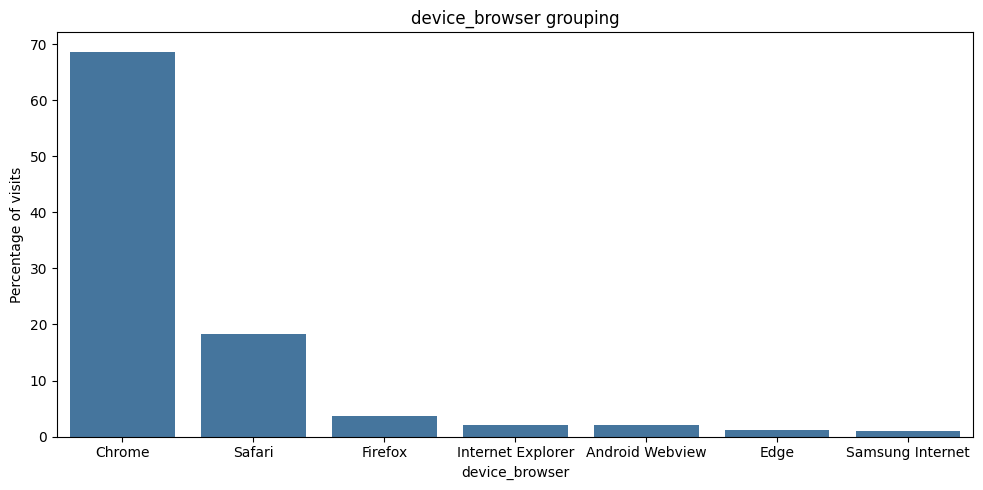

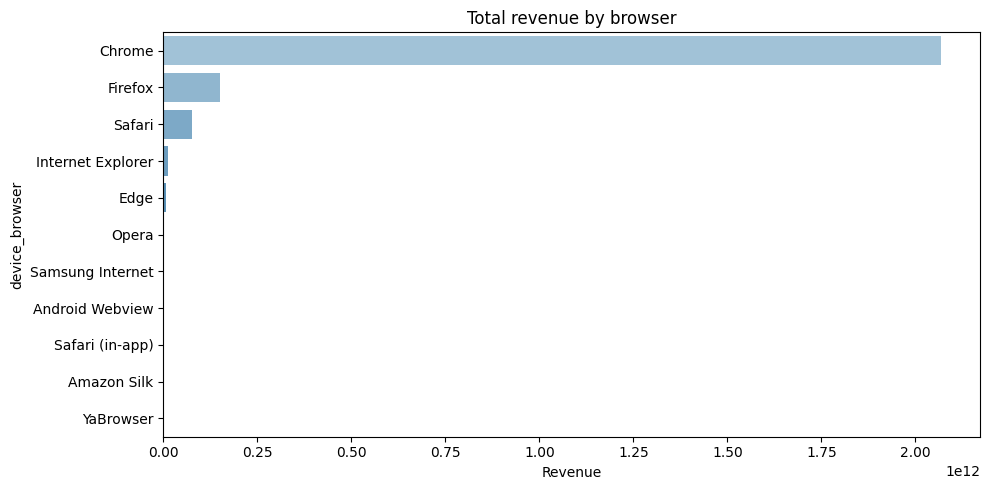

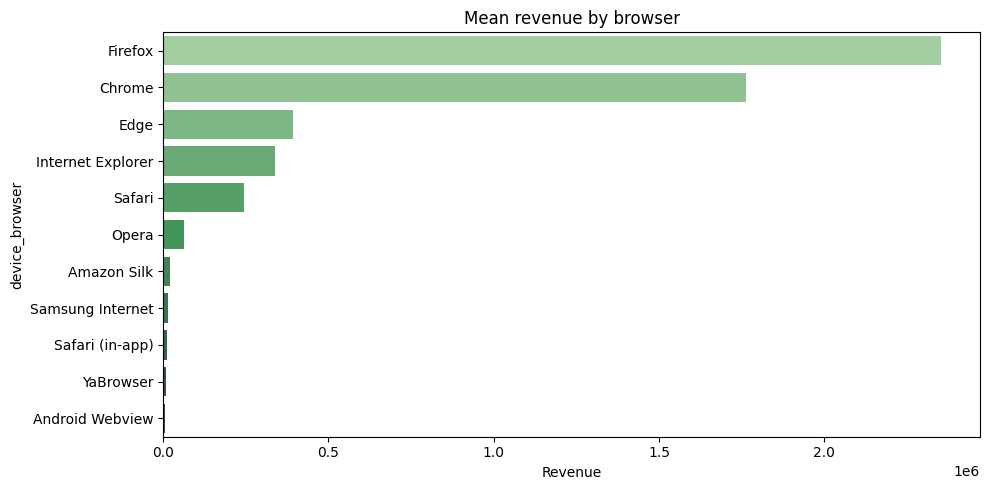

In [27]:
# Visits
barplot_percentage('device_browser', num_bars= 7)
# Revenue
group_revenue('device_browser', 'Total revenue by browser', True, size=(10,5))
group_revenue('device_browser', 'Mean revenue by browser', False, 'Greens_d',size=(10,5))

### 5.2 Device Category

**Desktop vs. Mobile**: 
- **Desktop**: ~69% of visits, significantly higher mean revenue (highest conversion rate, highest AOV)
- **Mobile**: ~28% of visits, much lower mean revenue (low conversion on small screens)
- **Tablet**: ~3% of visits, negligible revenue

This shows mobile optimization is critical - large gap between traffic and revenue suggests poor mobile purchase experience.

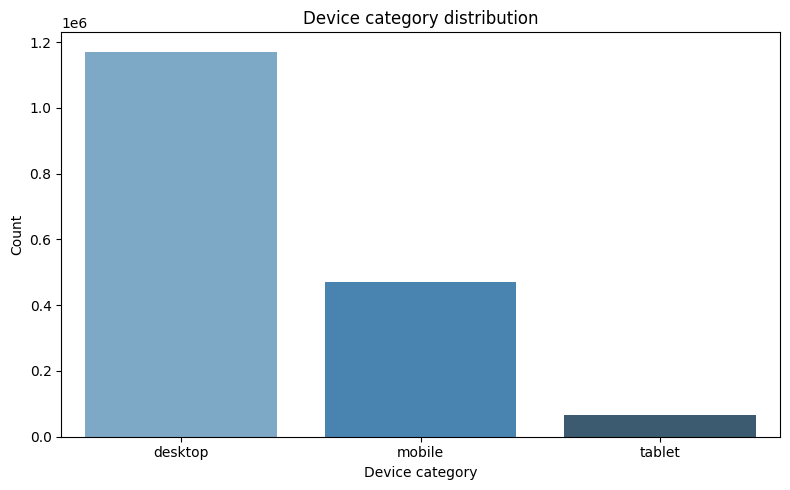

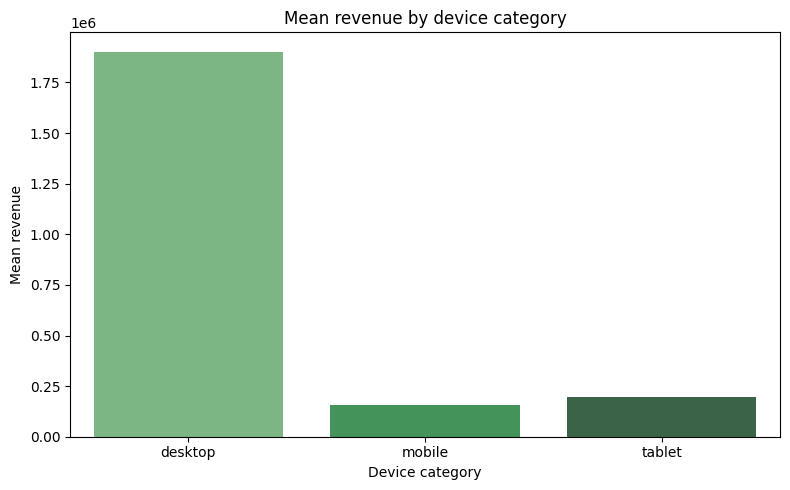

In [28]:
# Pie chart thay bằng barplot
dev_df = df['device_deviceCategory'].value_counts().to_frame().reset_index()
dev_df.columns = ['device_deviceCategory', 'count']
plt.figure(figsize=(8,5))
sns.barplot(x='device_deviceCategory', y='count', data=dev_df, palette='Blues_d')
plt.title('Device category distribution')
plt.xlabel('Device category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# Revenue
tmp = df.groupby('device_deviceCategory')['totals_transactionRevenue'].mean().to_frame().reset_index()
plt.figure(figsize=(8,5))
sns.barplot(x='device_deviceCategory', y='totals_transactionRevenue', data=tmp, palette='Greens_d')
plt.title('Mean revenue by device category')
plt.xlabel('Device category')
plt.ylabel('Mean revenue')
plt.tight_layout()
plt.show()

### 5.3 Operating System

**Windows** dominates (65%+ visits, 70%+ revenue), followed by **macOS** and **iOS**:
- **Desktop OS** (Windows, Mac): Higher revenue per visit
- **Mobile OS** (iOS, Android): Lower conversion despite significant traffic volume
- **Other OS**: Minimal traffic and revenue

OS distribution closely mirrors device category (desktop OSes = higher revenue), indicating device type is the primary driver, not OS itself.

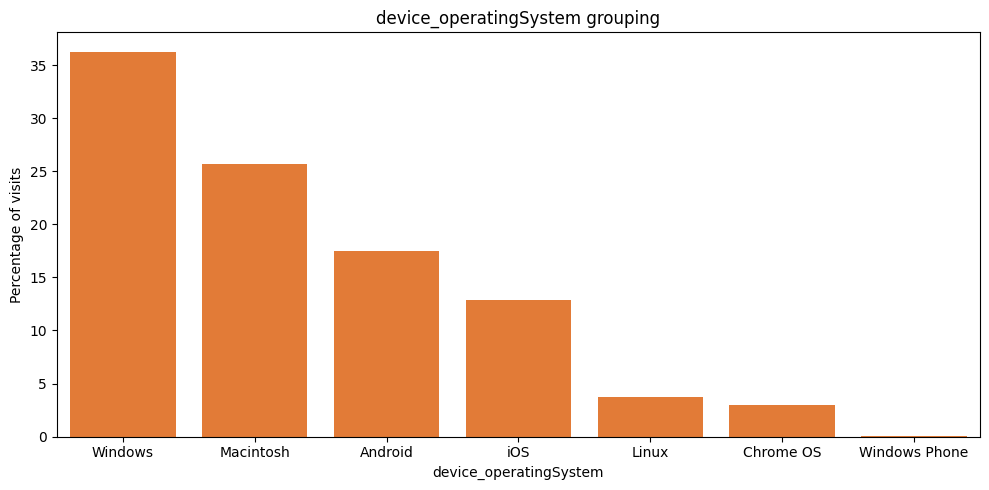

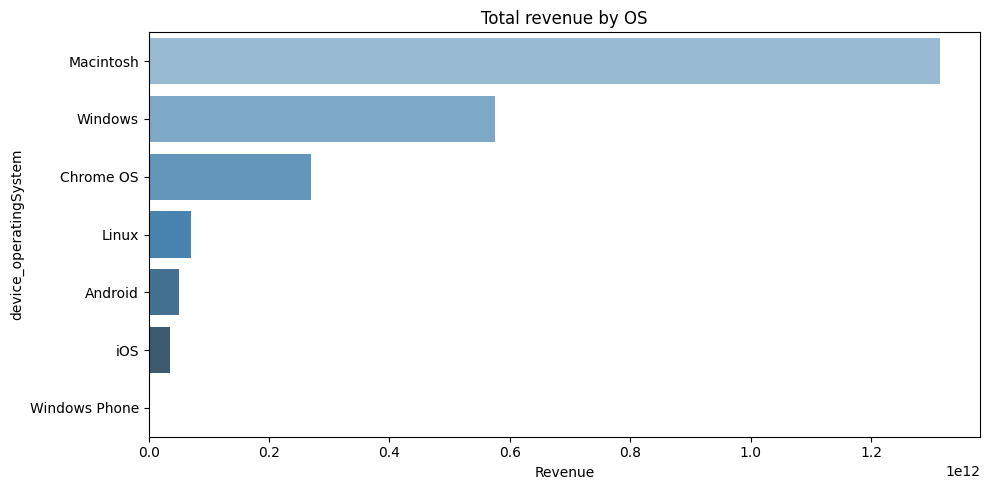

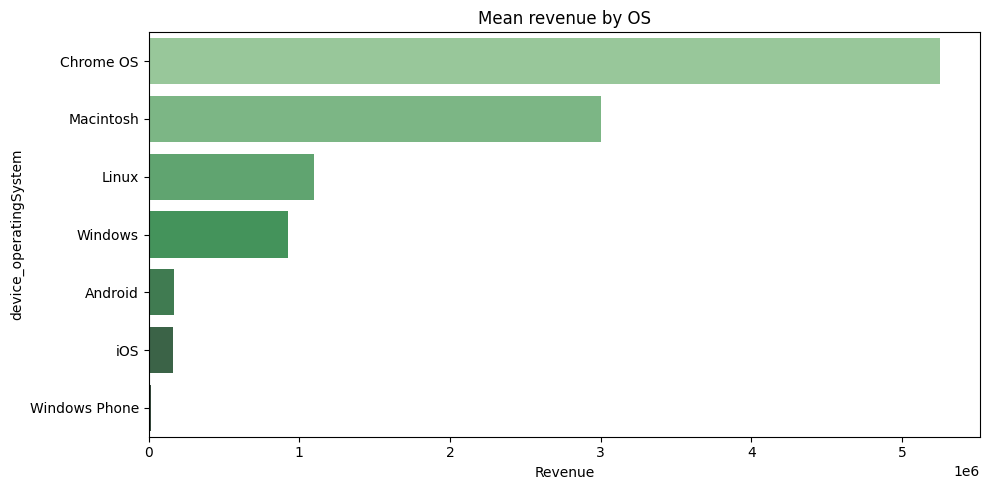

In [52]:
barplot_percentage('device_operatingSystem', num_bars = 7, color1='#ff751a')
# Revenue
group_revenue('device_operatingSystem', 'Total revenue by OS', True, 'Blues_d', size=(10,5))
group_revenue('device_operatingSystem', 'Mean revenue by OS', False, 'Greens_d', size=(10,5))

## 6. Traffic Source

Traffic source tracks how users discover GStore:
- **source**: Where traffic originated (google, yahoo, facebook, direct, etc.)
- **medium**: Type of traffic (organic, cpc, referral, none/direct)
- **campaign**: Marketing campaign name (highly sparse, 84% missing)
- **keyword**: Search keyword for organic search (95%+ missing)
- **referralPath**: Referring page URL path (67% missing)

**High cardinality and sparsity**: Many features have thousands of unique values with low frequency. Strategic feature engineering needed:
- Group low-frequency sources into "other"
- Focus on medium (organic/cpc/referral) rather than specific sources
- Drop ultra-sparse columns like campaign/keyword

## 7. User-Level Analysis

Aggregating session-level data to user-level reveals customer behavior patterns:
- **Repeat visit frequency**: How often users return
- **Total engagement**: Cumulative hits, pageviews, bounces across all visits
- **Purchase history**: How many users actually convert, total revenue per user
- **Customer segmentation**: Identify VIP customers, one-time buyers, engaged browsers

### 7.1 Visits per User

User retention and repeat visit patterns. Most users are one-time visitors, while a small segment returns multiple times. Understanding this distribution helps identify loyal customers vs. casual browsers.

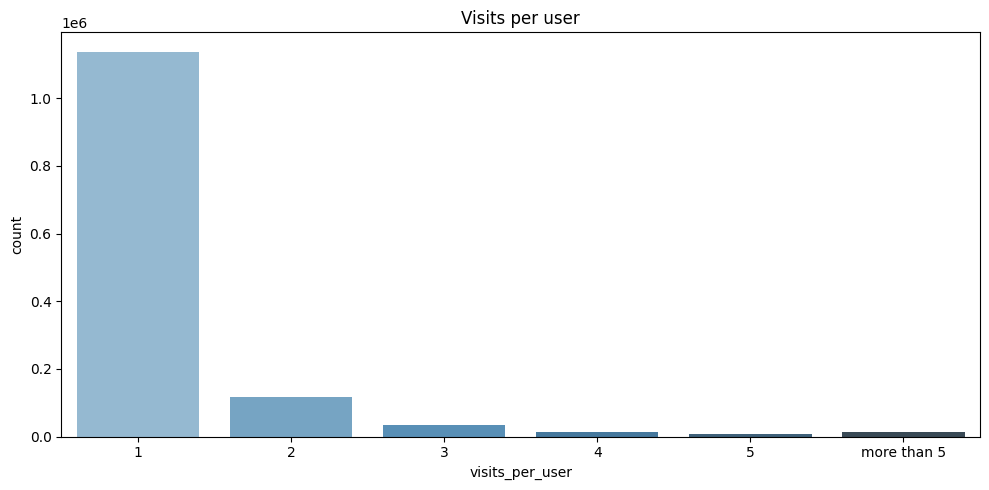

In [ ]:
tmp = df.groupby('fullVisitorId').size().value_counts().to_frame().reset_index()
tmp.columns = ['visits_per_user', 'count']
sum_ = tmp[tmp['visits_per_user'].astype('int16') > 5]['count'].sum()
tmp = pd.concat([tmp.head(5), pd.DataFrame({'visits_per_user': ['more than 5'], 'count': [sum_]})], ignore_index=True)
plt.figure(figsize=(10,5))
plt.title("Visits per user")
ax = sns.barplot(x=tmp['visits_per_user'], y=tmp['count'], palette='Blues_d')
plt.tight_layout()
plt.show()

### 7.2 Aggregated Metrics per User

This aggregates all session-level metrics for each user to understand overall engagement and purchasing behavior. We examine:
- **Total hits/pageviews**: How much the user browses across all visits
- **Total bounces**: Indicates browsing pattern consistency
- **Total transactions**: Purchase frequency for this user
- **Total revenue**: Lifetime value (LTV) for each customer

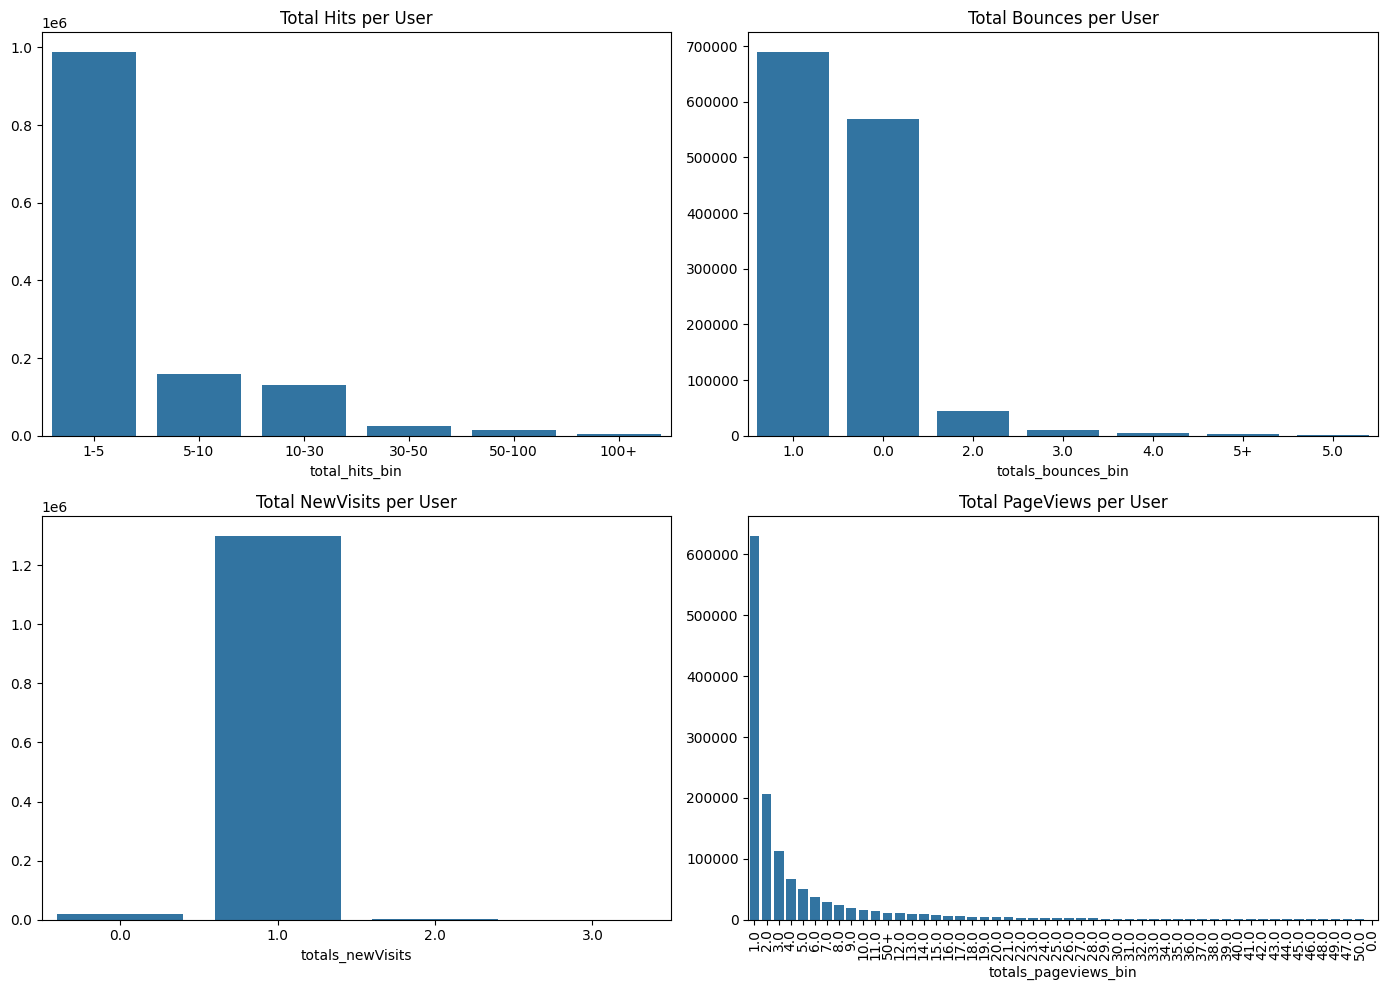

In [33]:
def getbin_hits(x):
    if x < 5:
        return "1-5"
    elif x < 10:
        return "5-10"
    elif x < 30:
        return "10-30"
    elif x < 50:
        return "30-50"
    elif x < 100:
        return "50-100"
    else:
        return "100+"

agg_dict = {}
for col in ["totals_bounces", "totals_hits", "totals_newVisits", "totals_pageviews", "totals_transactionRevenue"]:
    df[col] = df[col].astype('float')
    agg_dict[col] = "sum"
tmp = df.groupby("fullVisitorId").agg(agg_dict).reset_index()
tmp["total_hits_bin"] = tmp["totals_hits"].apply(getbin_hits)
tmp["totals_bounces_bin"] = tmp["totals_bounces"].apply(lambda x : str(x) if x <= 5 else "5+")
tmp["totals_pageviews_bin"] = tmp["totals_pageviews"].apply(lambda x : str(x) if x <= 50 else "50+")

t1 = tmp["total_hits_bin"].value_counts()
t2 = tmp["totals_bounces_bin"].value_counts()
t3 = tmp["totals_newVisits"].value_counts()
t4 = tmp["totals_pageviews_bin"].value_counts()

fig, axs = plt.subplots(2, 2, figsize=(14,10))
sns.barplot(x=t1.index[:20], y=t1.values[:20], ax=axs[0,0])
axs[0,0].set_title("Total Hits per User")
sns.barplot(x=t2.index[:20], y=t2.values[:20], ax=axs[0,1])
axs[0,1].set_title("Total Bounces per User")
sns.barplot(x=t3.index[:20], y=t3.values[:20], ax=axs[1,0])
axs[1,0].set_title("Total NewVisits per User")
sns.barplot(x=t4.index, y=t4.values, ax=axs[1,1])
axs[1,1].set_title("Total PageViews per User")
axs[1,1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 8. Class Imbalance Analysis

The target variable shows severe class imbalance - understanding the distribution is critical for model selection and evaluation metrics.

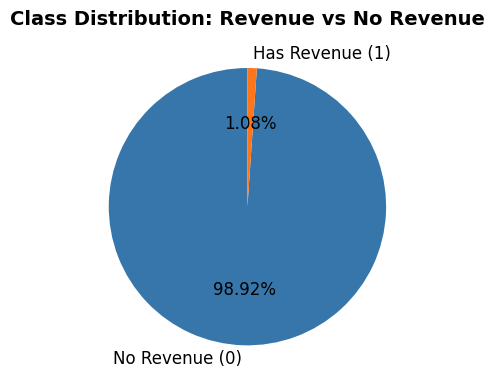

CLASS IMBALANCE STATISTICS
No Revenue (0): 1,689,823 sessions (98.92%)
Has Revenue (1): 18,514 sessions (1.08%)
Imbalance Ratio: 91.3:1


In [58]:
# Class imbalance pie chart
revenue_dist = df['has_revenue'].value_counts()
labels = ['No Revenue (0)', 'Has Revenue (1)']
colors = ['#3776ab', '#ff751a']
plt.figure(figsize=(6,4))
plt.pie(revenue_dist.values, labels=labels, autopct='%1.2f%%', colors=colors, startangle=90, textprops={'fontsize': 12})
plt.title('Class Distribution: Revenue vs No Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print("=" * 50)
print("CLASS IMBALANCE STATISTICS")
print("=" * 50)
print(f"No Revenue (0): {revenue_dist[0]:,} sessions ({100*revenue_dist[0]/len(df):.2f}%)")
print(f"Has Revenue (1): {revenue_dist[1]:,} sessions ({100*revenue_dist[1]/len(df):.2f}%)")
print(f"Imbalance Ratio: {revenue_dist[0]/revenue_dist[1]:.1f}:1")
print("=" * 50)

## 9. Traffic Source Deep Dive

Analyzing how users discover GStore and conversion patterns by source and medium.

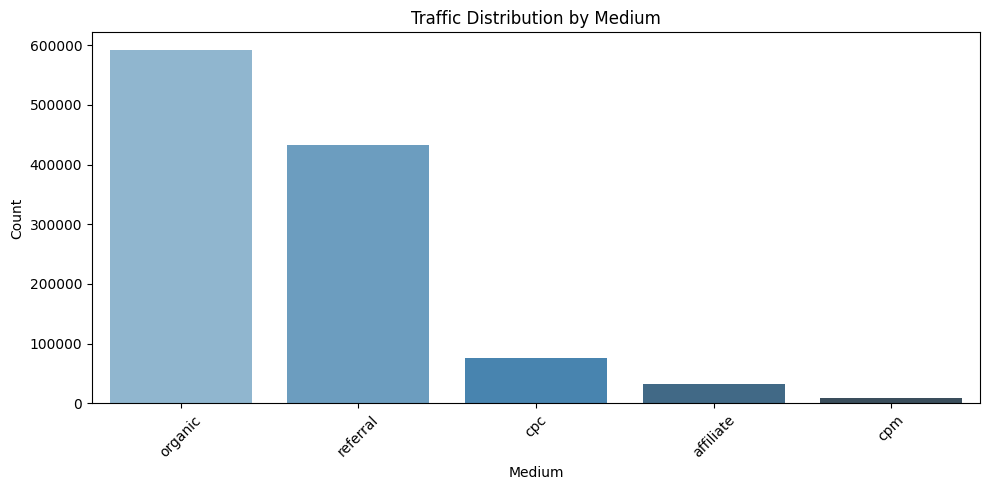


Traffic Medium Performance:
                               sum         mean   count  conversion_rate
trafficSource_medium                                                    
affiliate             8.650700e+08     26281.94   32915             0.05
cpc                   4.871199e+10    644312.92   75603             0.65
cpm                   1.080945e+11  12034566.91    8982             2.20
organic               4.180075e+11    706352.65  591783             0.71
referral              5.537271e+10    127892.48  432963             0.11


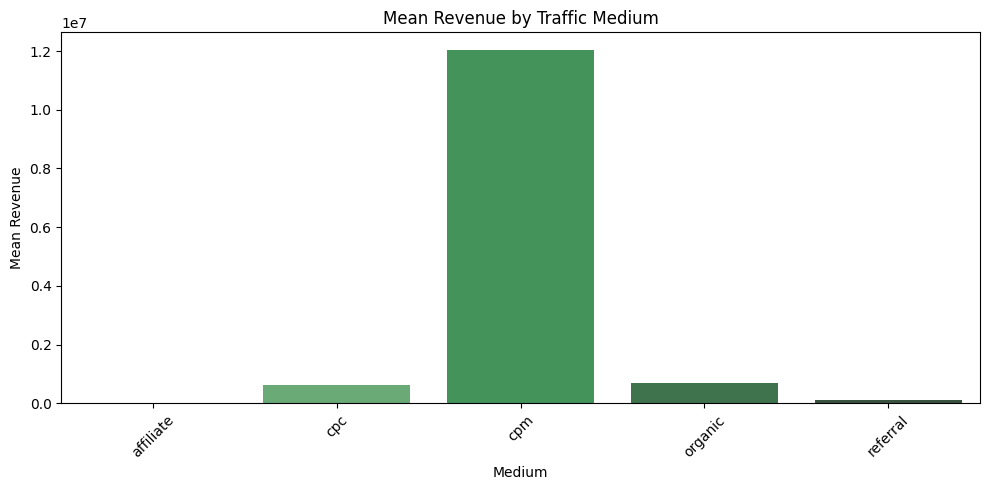

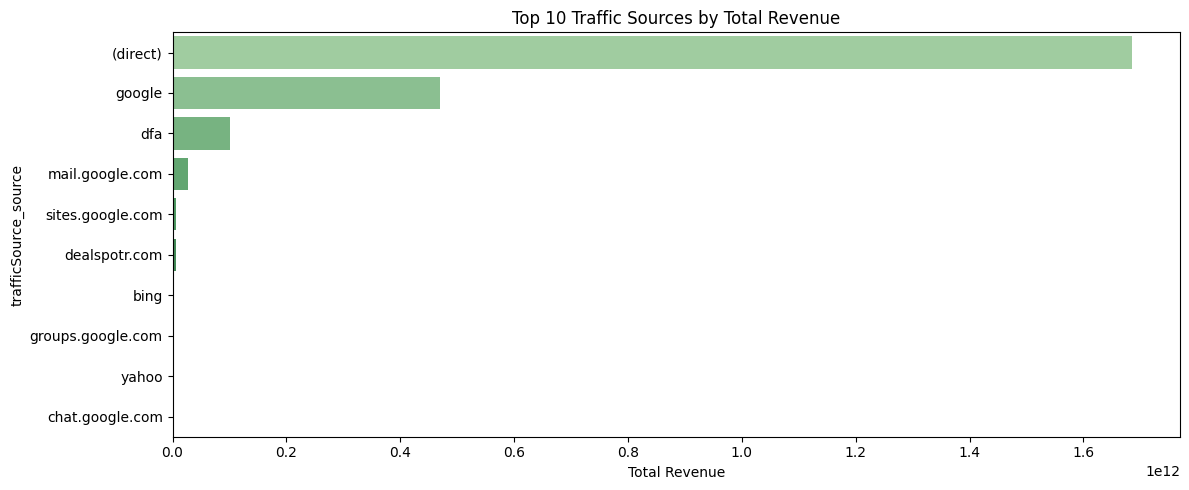

In [35]:
# Traffic medium analysis (organic, cpc, referral, etc.)
medium_dist = df['trafficSource_medium'].value_counts()
plt.figure(figsize=(10,5))
plt.title('Traffic Distribution by Medium')
sns.barplot(x=medium_dist.index, y=medium_dist.values, palette='Blues_d')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.xlabel('Medium')
plt.tight_layout()
plt.show()

# Revenue by medium
medium_revenue = df.groupby('trafficSource_medium')['totals_transactionRevenue'].agg(['sum', 'mean', 'count'])
medium_revenue['conversion_rate'] = df.groupby('trafficSource_medium')['has_revenue'].mean() * 100
print("\nTraffic Medium Performance:")
print(medium_revenue.round(2))

# Visualize mean revenue by medium
plt.figure(figsize=(10,5))
plt.title('Mean Revenue by Traffic Medium')
sns.barplot(x=medium_revenue.index, y=medium_revenue['mean'], palette='Greens_d')
plt.xticks(rotation=45)
plt.ylabel('Mean Revenue')
plt.xlabel('Medium')
plt.tight_layout()
plt.show()

# Top 10 sources by revenue
source_revenue = df.groupby('trafficSource_source')['totals_transactionRevenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
plt.title('Top 10 Traffic Sources by Total Revenue')
sns.barplot(x=source_revenue.values, y=source_revenue.index, palette='Greens_d', orient='h')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

## 10. Feature Correlation & Relationships

Examining correlations between numerical features to identify multicollinearity and feature relationships.

Numerical columns available: 32
Columns: ['visitId', 'visitNumber', 'visitStartTime', 'totals_hits', 'totals_pageviews', 'totals_bounces', 'totals_newVisits', 'totals_sessionQualityDim', 'totals_timeOnSite', 'totals_transactions', 'totals_transactionRevenue', 'totals_totalTransactionRevenue', 'trafficSource_adwordsClickInfo.page', 'customDimensions_count', 'customDimensions_index', 'Date_Year', 'Date_Month', 'Date_Day', 'Date_Dayofweek', 'Date_Dayofyear', 'Date_Week', 'Date_Is_month_end', 'Date_Is_month_start', 'Date_Is_quarter_end', 'Date_Is_quarter_start', 'Date_Is_year_end', 'Date_Is_year_start', 'Date_Hour', 'transactionRevenue', 'transactionRevenue_dollar', 'target_log_revenue', 'has_revenue']

Top 10 Features Correlated with Revenue:
has_revenue                       1.000000
target_log_revenue                0.997756
totals_transactions               0.933784
totals_pageviews                  0.374970
totals_hits                       0.356637
totals_sessionQualityDim          0

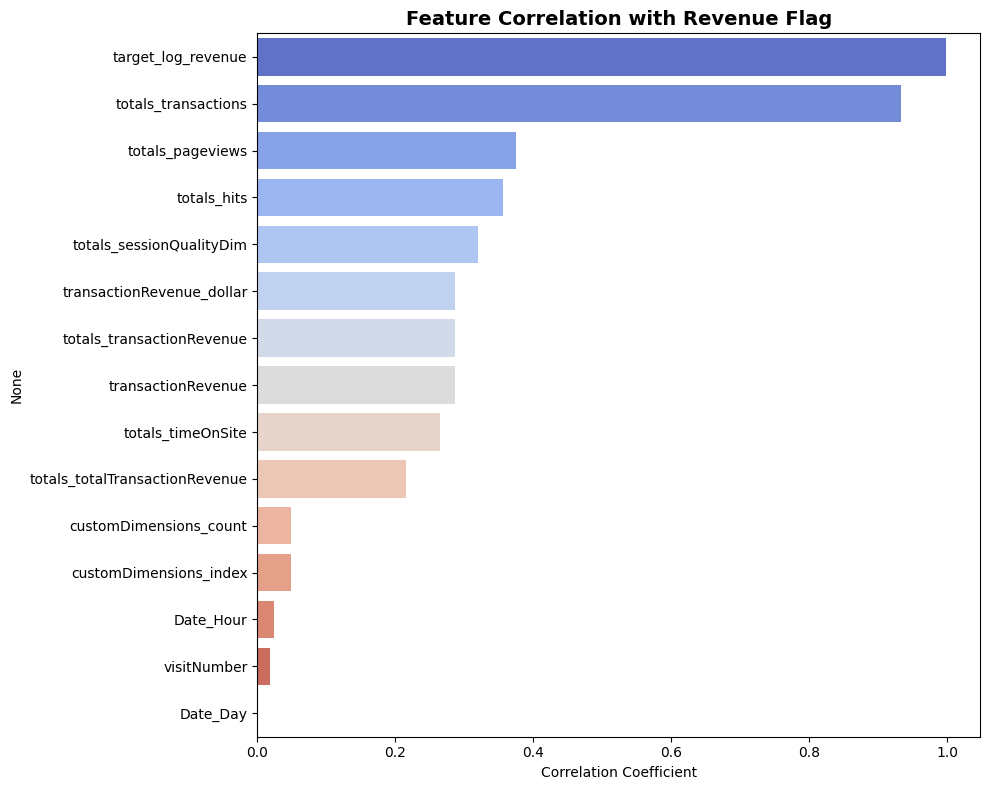

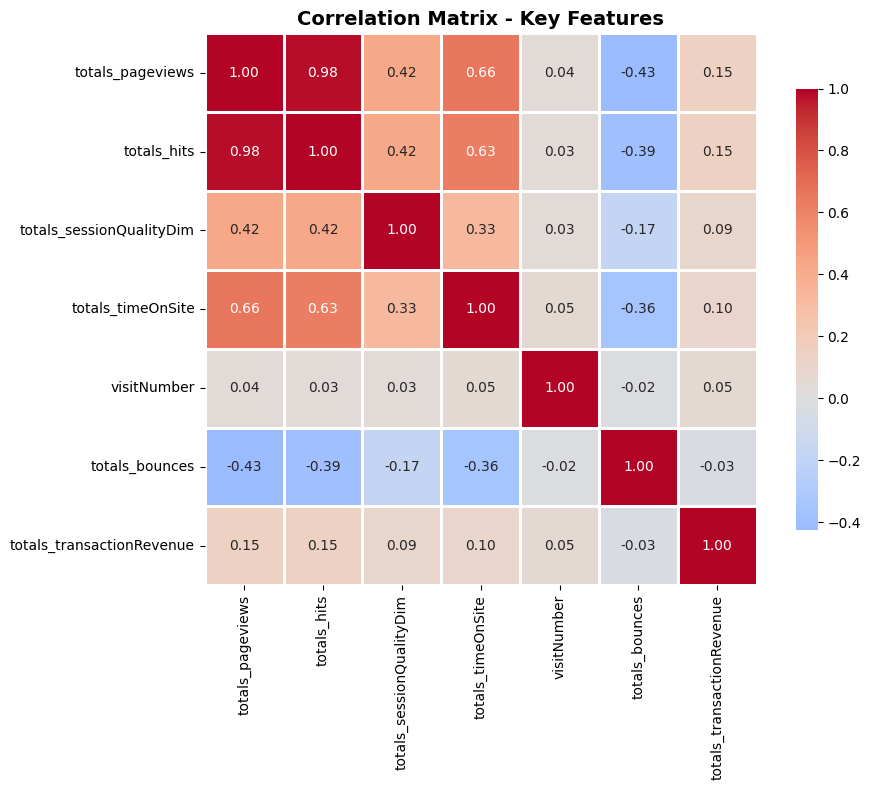


Key Observations:
- Strong correlation between hits and pageviews indicates high multicollinearity
- Both hits and pageviews are strongly correlated with revenue
- New visitors show similar patterns but with slightly lower correlation


In [49]:
# Select numerical columns for correlation analysis
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns available: {len(numerical_cols)}")
print(f"Columns: {numerical_cols}")

# Calculate correlation matrix
corr_matrix = df[numerical_cols].corr()

# Correlation with target variable (has_revenue)
target_corr = corr_matrix['has_revenue'].sort_values(ascending=False)
print("\nTop 10 Features Correlated with Revenue:")
print(target_corr.head(11))  # 11 to exclude 'has_revenue' itself

# Visualize correlation with target
fig, ax = plt.subplots(figsize=(10,8))
target_corr_filtered = target_corr[1:16]  # Top 15 excluding itself
sns.barplot(x=target_corr_filtered.values, y=target_corr_filtered.index, palette='coolwarm', ax=ax)
ax.set_title('Feature Correlation with Revenue Flag', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Full correlation heatmap (subset of key features to avoid too large matrix)
key_features = ['totals_pageviews', 'totals_hits', 'totals_sessionQualityDim', 
                'totals_timeOnSite', 'visitNumber', 'totals_bounces', 'totals_transactionRevenue']
key_features = [col for col in key_features if col in df.columns]
corr_subset = df[key_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_subset, annot=True, cmap='coolwarm', center=0, square=True, 
            linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix - Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Strong correlation between hits and pageviews indicates high multicollinearity")
print("- Both hits and pageviews are strongly correlated with revenue")
print("- New visitors show similar patterns but with slightly lower correlation")

## 11. Summary & Key Insights

This EDA reveals critical patterns for predicting customer revenue in the Google Store dataset:

#### **1. SEVERE CLASS IMBALANCE**
- **98.92%** of sessions have zero revenue (no purchase)
- **Only 1.08%** of sessions result in any transaction
- **Imbalance Ratio:** 91.3:1
- **Recommendation:** Use stratified sampling, SMOTE, or weighted loss functions

#### **2. GEOGRAPHIC INSIGHTS**
- **US dominates:** 42% of visits but **94%** of total revenue
- **International markets** (India, UK, Canada) have high volume but minimal revenue
- Strong correlation between geography and purchasing behavior
- **Recommendation:** Geo-specific targeting and localization strategies

#### **3. DEVICE MATTERS SIGNIFICANTLY**
- **Desktop:** 68.58% visits, **$1.9M mean revenue** (highest conversion)
- **Mobile:** 27.59% visits, **$158K mean revenue** (low conversion)
- **Revenue Ratio:** Desktop generates **12.1x** more revenue than mobile
- **Recommendation:** Prioritize desktop UX optimization, improve mobile checkout experience

#### **4. ENGAGEMENT DRIVES CONVERSION**
- **Strong correlation** between hits/pageviews and revenue
- **No-revenue sessions:** Mean 4.1 hits, Median 1 hit
- **Revenue sessions:** Mean 35.1 hits, Median 27 hits
- **Bounce rate:** Perfect separator - bounced sessions = 0 revenue (0 out of all bounced)
- **Recommendation:** Use engagement metrics as top predictors

#### **5. TRAFFIC SOURCE MATTERS**
- **Organic and Referral** traffic show higher conversion than direct
- **Campaign data:** 94% missing - limited predictive value
- **Source medium** (organic/cpc/referral) more important than specific source
- **Recommendation:** Focus on traffic medium, group low-frequency sources

#### **6. USER BEHAVIOR PATTERNS**
- **86% are one-time visitors** - higher than expected
- **Repeat visitors** show significantly higher LTV
- **New vs returning customer** distinction is important for modeling
- **Recommendation:** Implement customer lifecycle segmentation

#### **7. FEATURE ENGINEERING OPPORTUNITIES**
- **Hits ↔ PageViews correlation:** 0.9798 (extremely high multicollinearity)
- **Consider:** Drop one of these features to reduce redundancy
- **Session aggregations:** Available for user-level features
- **Time-based features:** Can capture seasonal/temporal patterns
- **Recommendation:** Create engagement_score, RFM metrics, time_on_site

#### **8. MODELING CONSIDERATIONS**
- **Extreme class imbalance** requires careful metric selection
- **Avoid accuracy** metric → Use AUC, Precision-Recall, F1-score instead
- **Stratified cross-validation** essential for evaluation
- **Revenue prediction:** Highly skewed → log transformation necessary
- **Missing values:** Handle campaign (~94%) and metro (~77%) strategically
